<a href="https://colab.research.google.com/github/veenasri16/Crop-Recommendation-using-Ensemble-learning/blob/main/mini2Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIBRARIES

In [ ]:
pip install xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

DATASET

Packages and Libraries

In [ ]:
!pip install -q xgboost catboost

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

Dataset

In [ ]:
df = pd.read_csv("Crop_recommendation.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
display(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Missing Values
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Statistics


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
le = LabelEncoder()

df["label"] = le.fit_transform(df["label"])

X = df.drop("label", axis=1)

y = df["label"]

print("Classes:")

print(le.classes_)

Classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


Training and Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)

print("Testing Samples:", X_test.shape)

Training Samples: (1760, 7)
Testing Samples: (440, 7)


Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9931818181818182


XG Boost

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9863636363636363


CAT Boost

In [ ]:
cat = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.1,
    verbose=0,
    random_seed=42
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)

cat_acc = accuracy_score(y_test, cat_pred)

print("CatBoost Accuracy:", cat_acc)

CatBoost Accuracy: 0.9931818181818182


Soft Voting

In [ ]:
vote = VotingClassifier(

    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("cat", cat)
    ],

    voting="soft"

)

vote.fit(X_train, y_train)

vote_pred = vote.predict(X_test)

vote_acc = accuracy_score(y_test, vote_pred)

print("Voting Ensemble Accuracy:", vote_acc)

Voting Ensemble Accuracy: 0.9954545454545455


Stacking ensemble model

In [ ]:
stack = StackingClassifier(

    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("cat", cat)
    ],

    final_estimator=LogisticRegression(max_iter=1000),

    cv=5

)

stack.fit(X_train, y_train)

stack_pred = stack.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)

print("Stacking Ensemble Accuracy:", stack_acc)

Stacking Ensemble Accuracy: 0.9954545454545455


In [ ]:
print(classification_report(y_test, stack_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

Confusion Matrix

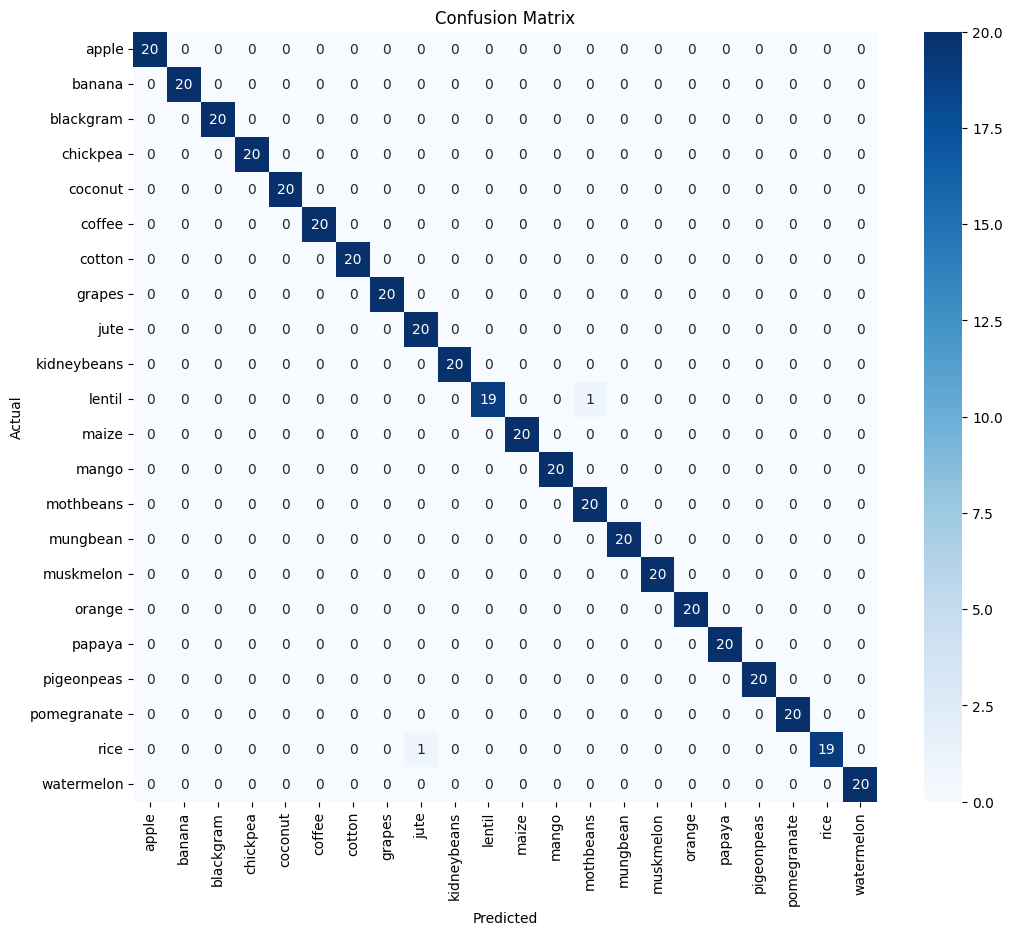

In [ ]:
cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

ROC Curve

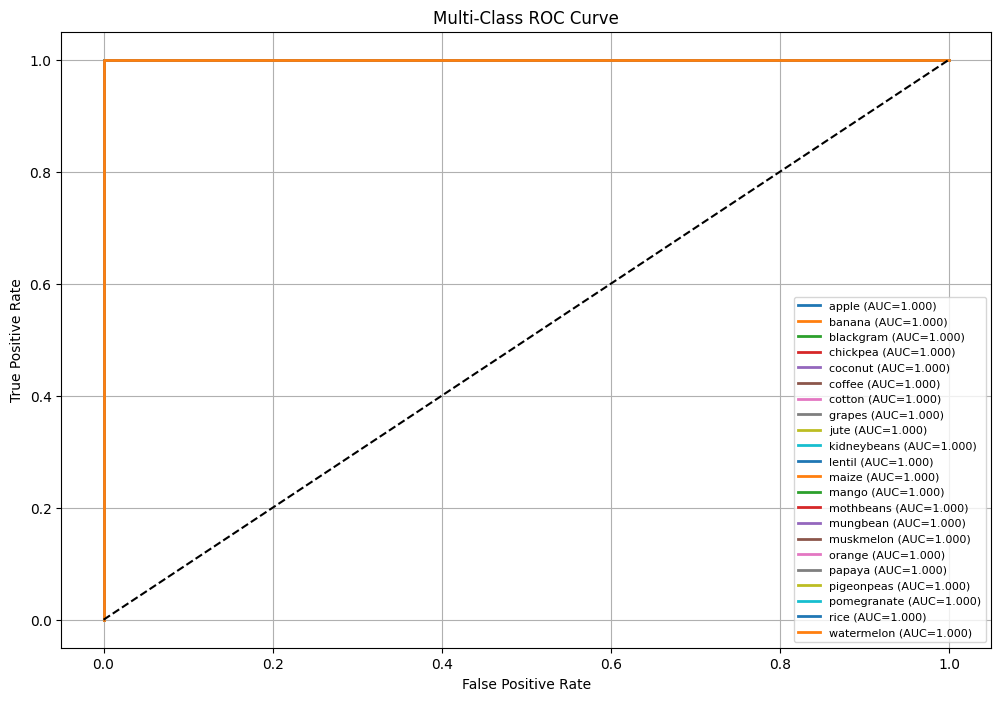

In [ ]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))

y_score = stack.predict_proba(X_test)

plt.figure(figsize=(12,8))

for i in range(len(le.classes_)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{le.classes_[i]} (AUC={roc_auc:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Multi-Class ROC Curve")

plt.legend(loc="lower right", fontsize=8)

plt.grid()

plt.show()

Feature Importance

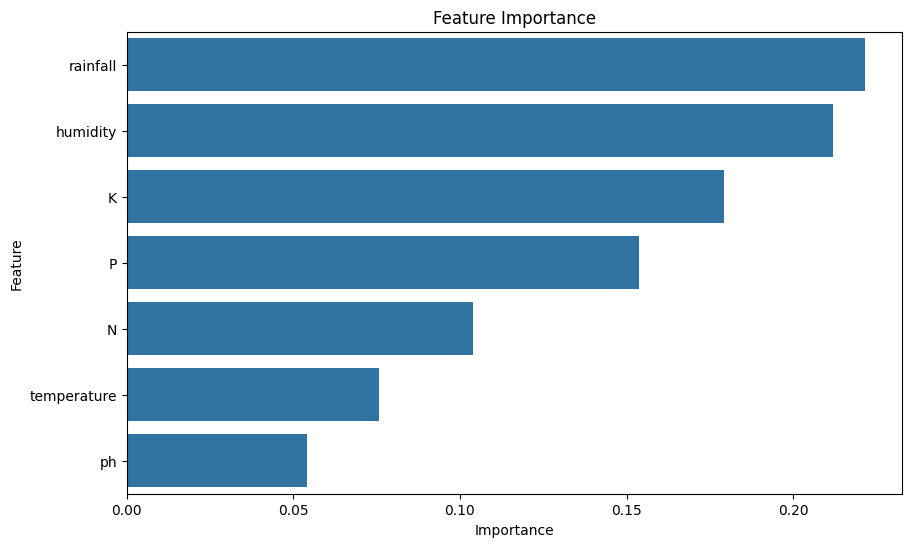

In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [ ]:
results = pd.DataFrame({

    "Model":[

        "Random Forest",

        "XGBoost",

        "CatBoost",

        "Voting Ensemble",

        "Stacking Ensemble"

    ],

    "Accuracy":[

        rf_acc,

        xgb_acc,

        cat_acc,

        vote_acc,

        stack_acc

    ]

})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

display(results)

,Model,Accuracy
4,Stacking Ensemble,0.995455
3,Voting Ensemble,0.995455
0,Random Forest,0.993182
2,CatBoost,0.993182
1,XGBoost,0.986364


In [ ]:
best_model = results.iloc[0]

print("="*40)

print("Best Model :", best_model["Model"])

print("Accuracy :", round(best_model["Accuracy"]*100,2), "%")

print("="*40)

Best Model : Stacking Ensemble
Accuracy : 99.55 %
